# Dependencies Installation

In [1]:
!pip install nvcc4jupyter

In [2]:
!sudo apt-get update
!sudo apt-get install -y libopencv-dev

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [93.4 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,915 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.2 MB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,004 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-bac

In [3]:
%load_ext nvcc4jupyter

Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmpsgqui81j".


# Reading the Image with Python to Ensure Correct Access

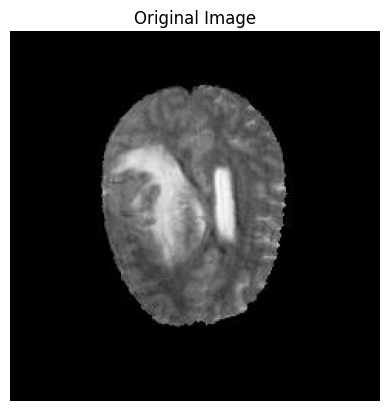

In [4]:
from matplotlib import pyplot as plt
import cv2

image = cv2.imread("/content/drive/MyDrive/(PUBLIC) Parallel Project/Sample_Images/Sample_6_Slice_97.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

# Random Mini-Batch K-Means Algorithm

In [5]:
%%cuda  -c "-I/usr/include/opencv4 -lopencv_core -lopencv_imgcodecs -lopencv_highgui"

#include <opencv2/opencv.hpp>
#include <cuda_runtime.h>
#include <iostream>
#include <vector>
#include <time.h>

using namespace cv;
using namespace std;

#define CHANNELS 3
#define K 3                  // number of clusters
#define BATCH_SIZE 1024        // Size of the random sampled batch
#define MAX_ITERS 50             // K-Means Iterations


// Mini-Batch K-Means Centroid Update Kernel

__global__ void miniBatchKmeansKernel(
    unsigned char* image,
    int* batch_indices,
    float* centroids,
    int* centroid_counts,
    int* labels,
    int total_pixels,
    int batch_size)
{
    int tid = blockIdx.x * blockDim.x + threadIdx.x;

    if (tid >= batch_size)
        return;

    int pixel_idx = batch_indices[tid];

    if(pixel_idx >= total_pixels)
        return;

    int rgbOffset = pixel_idx * CHANNELS;

    float r = image[rgbOffset];
    float g = image[rgbOffset + 1];
    float b = image[rgbOffset + 2];

    // Find nearest centroid

    float minDist = 1e20;
    int bestCluster = 0;

    #pragma unroll
    for(int c = 0; c < K; c++)
    {
        float cr = centroids[c * CHANNELS];
        float cg = centroids[c * CHANNELS + 1];
        float cb = centroids[c * CHANNELS + 2];

        float dist =
            (r - cr)*(r - cr) +
            (g - cg)*(g - cg) +
            (b - cb)*(b - cb);

        if(dist < minDist)
        {
            minDist = dist;
            bestCluster = c;
        }
    }

    // Store temporary batch label

    labels[pixel_idx] = bestCluster;

    // Incremental centroid update (per every assigned pixel)

    int old_count =
        atomicAdd(&centroid_counts[bestCluster], 1);

    float eta = 1.0f / (old_count + 1);

    atomicAdd(
        &centroids[bestCluster * CHANNELS],
        eta * (r - centroids[bestCluster * CHANNELS]));

    atomicAdd(
        &centroids[bestCluster * CHANNELS + 1],
        eta * (g - centroids[bestCluster * CHANNELS + 1]));

    atomicAdd(
        &centroids[bestCluster * CHANNELS + 2],
        eta * (b - centroids[bestCluster * CHANNELS + 2]));
}

// Final Full-Image Assignment Kernel

__global__ void finalAssignmentKernel(
    unsigned char* image,
    float* centroids,
    int* labels,
    int total_pixels)
{
    int idx =
        blockIdx.x * blockDim.x + threadIdx.x;

    if(idx >= total_pixels)
        return;

    // Read pixel

    int rgbOffset = idx * CHANNELS;

    float r = image[rgbOffset];
    float g = image[rgbOffset + 1];
    float b = image[rgbOffset + 2];

    // Find nearest centroid

    float minDist = 1e20;
    int bestCluster = 0;

    #pragma unroll
    for(int c = 0; c < K; c++)
    {
        float cr = centroids[c * CHANNELS];
        float cg = centroids[c * CHANNELS + 1];
        float cb = centroids[c * CHANNELS + 2];

        float dist =
            (r - cr)*(r - cr) +
            (g - cg)*(g - cg) +
            (b - cb)*(b - cb);

        if(dist < minDist)
        {
            minDist = dist;
            bestCluster = c;
        }
    }

    // Store final label

    labels[idx] = bestCluster;
}

// Random mini-batch Sampling

void generateMiniBatch(
    vector<int>& batch_indices,
    int total_pixels)
{
    for(int i = 0; i < BATCH_SIZE; i++)
    {
        batch_indices[i] = rand() % total_pixels;
    }
}


int main()
{
    srand(time(NULL));

    // --------------------------------------------------------
    // Read image
    // --------------------------------------------------------

    Mat image = imread("/content/drive/MyDrive/(PUBLIC) Parallel Project/Sample_Images/Sample_6_Slice_97.png");

    if(image.empty())
    {
        cout << "Image not found!" << endl;
        return -1;
    }

    image.convertTo(image, CV_8UC3);

    int width  = image.cols;
    int height = image.rows;

    int total_pixels = width * height;



    unsigned char* h_image = image.data;


    int* h_labels =
        (int*)malloc(total_pixels * sizeof(int));

    // Initialize centroids randomly

    float h_centroids[K * CHANNELS];

    for(int c = 0; c < K; c++)
    {
        int rand_pixel = rand() % total_pixels;

        h_centroids[c * CHANNELS] =
            h_image[rand_pixel * CHANNELS];

        h_centroids[c * CHANNELS + 1] =
            h_image[rand_pixel * CHANNELS + 1];

        h_centroids[c * CHANNELS + 2] =
            h_image[rand_pixel * CHANNELS + 2];
    }

    // Cluster counts

    int h_counts[K];

    for(int i = 0; i < K; i++)
        h_counts[i] = 1;

    // Mini-batch indices that will be copied (not the batch pixels)

    vector<int> batch_indices(BATCH_SIZE);


    unsigned char* d_image;
    float* d_centroids;
    int* d_counts;
    int* d_labels;
    int* d_batch_indices;

    cudaMalloc(
        &d_image,
        total_pixels * CHANNELS * sizeof(unsigned char));

    cudaMalloc(
        &d_centroids,
        K * CHANNELS * sizeof(float));

    cudaMalloc(
        &d_counts,
        K * sizeof(int));

    cudaMalloc(
        &d_labels,
        total_pixels * sizeof(int));

    cudaMalloc(
        &d_batch_indices,
        BATCH_SIZE * sizeof(int));


    cudaMemcpy(
        d_image,
        h_image,
        total_pixels * CHANNELS * sizeof(unsigned char),
        cudaMemcpyHostToDevice);

    cudaMemcpy(
        d_centroids,
        h_centroids,
        K * CHANNELS * sizeof(float),
        cudaMemcpyHostToDevice);

    cudaMemcpy(
        d_counts,
        h_counts,
        K * sizeof(int),
        cudaMemcpyHostToDevice);

    // CUDA configuration

    int threadsPerBlock = 256;

    int blocks =
        (BATCH_SIZE + threadsPerBlock - 1)
        / threadsPerBlock;

    // Mini-Batch K-Means Iterations

    for(int iter = 0; iter < MAX_ITERS; iter++)
    {
        generateMiniBatch(batch_indices, total_pixels);

        cudaMemcpy(
            d_batch_indices,
            batch_indices.data(),
            BATCH_SIZE * sizeof(int),
            cudaMemcpyHostToDevice);

        miniBatchKmeansKernel<<<blocks, threadsPerBlock>>>(
            d_image,
            d_batch_indices,
            d_centroids,
            d_counts,
            d_labels,
            total_pixels,
            BATCH_SIZE);

        cudaDeviceSynchronize();

        cout << "Iteration "
             << iter
             << " completed"
             << endl;
    }

    // Final Full-Image Assignment

    int finalThreads = 256;

    int finalBlocks =
        (total_pixels + finalThreads - 1)
        / finalThreads;

    finalAssignmentKernel<<<
        finalBlocks,
        finalThreads>>>(
            d_image,
            d_centroids,
            d_labels,
            total_pixels);

    cudaDeviceSynchronize();

    // Copy final labels and centroids back to host

    cudaMemcpy(
        h_labels,
        d_labels,
        total_pixels * sizeof(int),
        cudaMemcpyDeviceToHost);


    cudaMemcpy(
        h_centroids,
        d_centroids,
        K * CHANNELS * sizeof(float),
        cudaMemcpyDeviceToHost);

    // Create the segmented image and save it

    Mat segmented(height, width, CV_8UC3);

    for(int y = 0; y < height; y++)
    {
        for(int x = 0; x < width; x++)
        {
            int idx = y * width + x;

            int cluster = h_labels[idx];

            segmented.at<Vec3b>(y, x)[0] =
                (unsigned char)h_centroids[cluster * CHANNELS];

            segmented.at<Vec3b>(y, x)[1] =
                (unsigned char)h_centroids[cluster * CHANNELS + 1];

            segmented.at<Vec3b>(y, x)[2] =
                (unsigned char)h_centroids[cluster * CHANNELS + 2];
        }
    }



    imwrite("segmented.png", segmented);

    cout << "Segmented image saved successfully!"
         << endl;

    // Free the allocated GPU memory

    free(h_labels);

    cudaFree(d_image);
    cudaFree(d_centroids);
    cudaFree(d_counts);
    cudaFree(d_labels);
    cudaFree(d_batch_indices);

    return 0;
}

Iteration 0 completed
Iteration 1 completed
Iteration 2 completed
Iteration 3 completed
Iteration 4 completed
Iteration 5 completed
Iteration 6 completed
Iteration 7 completed
Iteration 8 completed
Iteration 9 completed
Iteration 10 completed
Iteration 11 completed
Iteration 12 completed
Iteration 13 completed
Iteration 14 completed
Iteration 15 completed
Iteration 16 completed
Iteration 17 completed
Iteration 18 completed
Iteration 19 completed
Iteration 20 completed
Iteration 21 completed
Iteration 22 completed
Iteration 23 completed
Iteration 24 completed
Iteration 25 completed
Iteration 26 completed
Iteration 27 completed
Iteration 28 completed
Iteration 29 completed
Iteration 30 completed
Iteration 31 completed
Iteration 32 completed
Iteration 33 completed
Iteration 34 completed
Iteration 35 completed
Iteration 36 completed
Iteration 37 completed
Iteration 38 completed
Iteration 39 completed
Iteration 40 completed
Iteration 41 completed
Iteration 42 completed
Iteration 43 complete

# Visualizing the Original and Segmented Images

Original image shape : (240, 240, 3)
segmented image shape : (240, 240, 3)


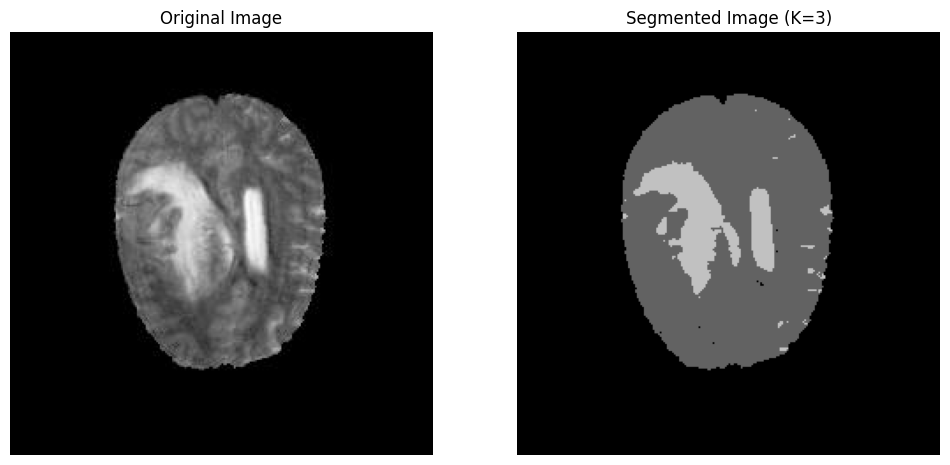

In [6]:
import matplotlib.pyplot as plt
import cv2
import os

input_path = "/content/drive/MyDrive/(PUBLIC) Parallel Project/Sample_Images/Sample_6_Slice_97.png"
output_path = "/content/segmented.png"

if os.path.exists(output_path):
    # Read images
    original = cv2.imread(input_path)
    segmented = cv2.imread(output_path)

    # Convert BGR to RGB for correct color display in Matplotlib
    if original is not None:
        original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
        print(f"Original image shape : {original.shape}")
    if segmented is not None:
        segmented = cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB)
        print(f"segmented image shape : {segmented.shape}")

    # Plot side by side
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    if original is not None:
        ax[0].imshow(original)
    ax[0].set_title("Original Image")
    ax[0].axis("off")

    if segmented is not None:
        ax[1].imshow(segmented)
    ax[1].set_title("Segmented Image (K=3)")
    ax[1].axis("off")

    plt.show()
else:
    print("Error: Output image not found. The C++ code might have failed to run.")